# Project question generator



## 1. Instalasi Library

In [ ]:
!pip install transformers evaluate rouge_score sacrebleu accelerate -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00


import library


In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
import evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


Konfigurasi

In [ ]:
class Config:
    seed = 42
    model_name = 't5-small'
    max_input_length = 512
    max_target_length = 64
    batch_size = 16
    epochs = 3
    learning_rate = 2e-5
    weight_decay = 0.01
    train_samples = 15000
    valid_samples = 3000

cfg = Config()

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

Direktori output


In [ ]:
model_dir = './QG_Model'
os.makedirs(model_dir, exist_ok=True)

load dataset

In [ ]:
train_df = pd.read_csv('qg_train.csv')
valid_df = pd.read_csv('qg_valid.csv')

if len(train_df) > cfg.train_samples:
    train_df = train_df.sample(n=cfg.train_samples, random_state=cfg.seed).reset_index(drop=True)
if len(valid_df) > cfg.valid_samples:
    valid_df = valid_df.sample(n=cfg.valid_samples, random_state=cfg.seed).reset_index(drop=True)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")
display(train_df.head(2))

Train shape: (15000, 2)
Valid shape: (3000, 2)


,question,text
0,how many ascospores?,<answer> A single ascus will contain eight asc...
1,What award did Hayek receive in 1974?,<answer> Nobel Memorial Prize <context> Friedr...


peprocessing

In [ ]:
def preprocess_input(text):
    text = re.sub(r'<answer> (.*?) <context> (.*)', r'answer: \1 context: \2', text)
    return "generate question: " + text

def preprocess_target(text):
    return text

train_df['input_text'] = train_df['text'].apply(preprocess_input)
train_df['target_text'] = train_df['question'].apply(preprocess_target)

valid_df['input_text'] = valid_df['text'].apply(preprocess_input)
valid_df['target_text'] = valid_df['question'].apply(preprocess_target)

tokenizer

In [ ]:
tokenizer = T5Tokenizer.from_pretrained(cfg.model_name)

class QGDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, targets, tokenizer, max_input_len, max_target_len):
        self.inputs = inputs
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_text = str(self.inputs[idx])
        target_text = str(self.targets[idx])

        input_encodings = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        target_encodings = self.tokenizer(
            target_text,
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        labels = target_encodings['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': input_encodings['input_ids'].squeeze(),
            'attention_mask': input_encodings['attention_mask'].squeeze(),
            'labels': labels
        }

train_dataset = QGDataset(train_df['input_text'].values, train_df['target_text'].values, tokenizer, cfg.max_input_length, cfg.max_target_length)
valid_dataset = QGDataset(valid_df['input_text'].values, valid_df['target_text'].values, tokenizer, cfg.max_input_length, cfg.max_target_length)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

load model

In [ ]:
model = T5ForConditionalGeneration.from_pretrained(cfg.model_name)
model = model.to(device)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

set up training & evaluasi

In [ ]:
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    rouge_res = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    bleu_res = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        "rouge1": rouge_res["rouge1"],
        "rouge2": rouge_res["rouge2"],
        "rougeL": rouge_res["rougeL"],
        "bleu": bleu_res["score"]
    }

args = Seq2SeqTrainingArguments(
    output_dir=model_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=cfg.learning_rate,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    weight_decay=cfg.weight_decay,
    save_total_limit=2,
    num_train_epochs=cfg.epochs,
    predict_with_generate=True,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    logging_steps=100
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

training model

In [ ]:
trainer.train()
trainer.save_model(f"{model_dir}/best_model")
tokenizer.save_pretrained(f"{model_dir}/best_model")

/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,2.462975,2.179604,0.299299,0.120956,0.281684,8.538081
2,2.324749,2.105262,0.312592,0.129756,0.294600,9.319241
3,2.286461,2.087272,0.320281,0.135401,0.302065,9.829936


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./QG_Model/best_model/tokenizer_config.json',
 './QG_Model/best_model/tokenizer.json')

evaluation loss


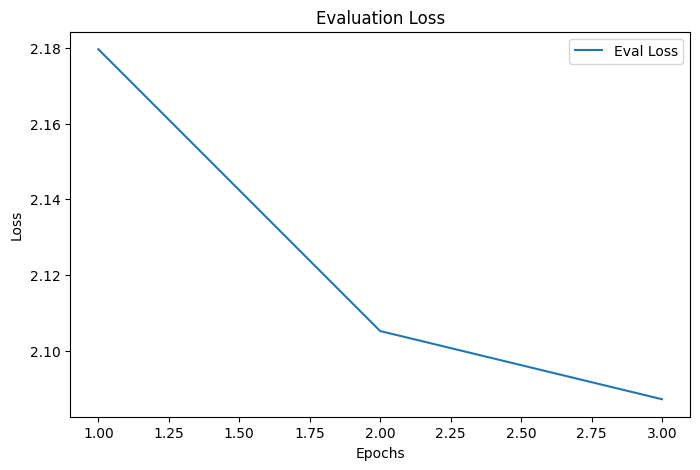

In [ ]:
log_history = trainer.state.log_history
train_loss = [x['loss'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
epochs = range(1, len(eval_loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, eval_loss, label='Eval Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evaluation Loss')
plt.legend()
plt.show()

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Bleu
2.286461,2.087272,3,0.320281,0.135401,0.302065,9.829936


{'eval_loss': 2.0872719287872314, 'eval_rouge1': 0.32028140606424105, 'eval_rouge2': 0.13540070360755777, 'eval_rougeL': 0.30206544260532653, 'eval_bleu': 9.829935757001875}


Review

In [ ]:
model.eval()
sample = valid_df.sample(5, random_state=cfg.seed)

for _, row in sample.iterrows():
    input_text = row['input_text']
    target_text = row['target_text']

    inputs = tokenizer(input_text, return_tensors='pt', max_length=cfg.max_input_length, truncation=True).to(device)
    outputs = model.generate(
        inputs['input_ids'],
        max_length=cfg.max_target_length,
        num_beams=4,
        early_stopping=True
    )

    pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("Input:", input_text.replace('generate question: ', ''))
    print("Target:", target_text)
    print("Predicted:", pred_text)
    print("-" * 50)

Input: answer: oon Jack's mum introduced some part-time jobs to Simon and Peter, context: Jack thought himself a basketball fan. He watched quite a lot of American NBA basketball games. Not only did he watch them, he spent much of his free time playing on the court too. Then came the final year of his middle school. All of his regular teammates stopped showing up on the court because they were simply too busy preparing for the high school entrance exam to play. He was, of course, under much stress himself, like everyone else. A good exam result meant a good high school; a mediocre score meant a mediocre school. _ . However, he loved basketball so much that he still found time to play, this time with a group of guys who were said to have skipped classes before. Some of his teachers started worrying about him. They asked his mother to go to school to let her know that Jack was hanging out with problem kids. When his mother returned home that day, she wanted to talk to Jack. Knowing the p

In [ ]:
testing

In [ ]:
def generate_question(context, answer):
    text = f"generate question: answer: {answer} context: {context}"
    inputs = tokenizer(text, return_tensors='pt', max_length=cfg.max_input_length, truncation=True).to(device)

    outputs = model.generate(
        inputs['input_ids'],
        max_length=cfg.max_target_length,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

context_demo = "Deep learning is part of a broader family of machine learning methods based on artificial neural networks with representation learning."
answer_demo = "machine learning methods"

print("Generated Question:", generate_question(context_demo, answer_demo))

Generated Question: what is deep learning?


learning curve

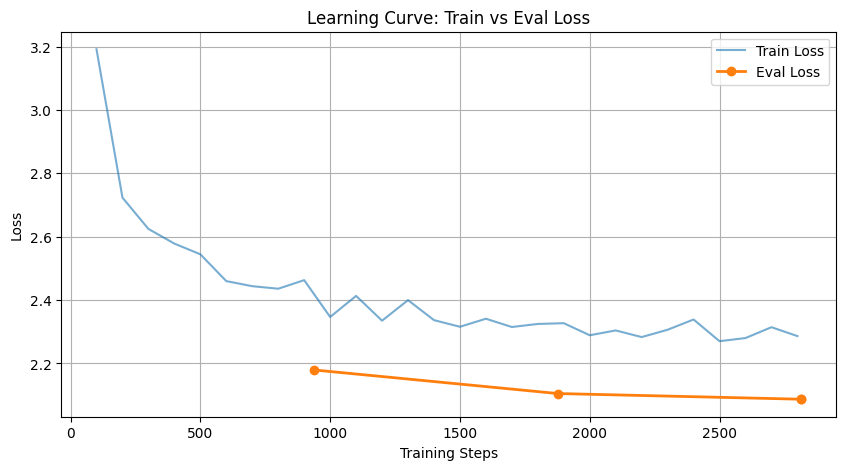

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x]
train_loss = [x['loss'] for x in log_history if 'loss' in x]

eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Train Loss', alpha=0.6)
plt.plot(eval_steps, eval_loss, label='Eval Loss', marker='o', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Learning Curve: Train vs Eval Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

drive_model_dir = '/content/drive/MyDrive/QG_Model/best_model'
os.makedirs(drive_model_dir, exist_ok=True)

trainer.save_model(drive_model_dir)
tokenizer.save_pretrained(drive_model_dir)

print(f"Model saved to: {drive_model_dir}")


Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/QG_Model/best_model
